# Statistical analyses

The general statistical checks available are `checkConstantSlope` and `allChanStats`. The former checks that the data in the requested channels are either constant, or varying at a constant rate. The latter reports the basic statistics of every channel for every flight-line.

Here we demonstrate their use on the Canobie airborne gravity gradiometer survey data.

Ensure you have run the `Prepare_XYZ` notebook first so that the Canobie data are prepared for review.

___

First, import the required modules, and set the path to the geowhizz files.

In [1]:
from pathlib import Path

import pegasusQC as qc

In [2]:
canobieHDF_file = Path(r'./CanobieData/Canobie.hdf5')
canobieHDF_plan = Path(r'./CanobieData/CanobiePlan.hdf5')

In [ ]:
if not canobieHDF_file.exists():
    %run ./Prepare_CanobieData.ipynb

___

** Constant slope** analysis uses first differences along each survey line to check that the requested channels are either of constant value, or vary at a fixed rate along each flight-line.

You can choose the channels to check from those listed by `reportChannels` or `reportWhizz`.

The cell below shows the channels selected from the Canobie data. In this case, only the two time channels are occasionally failing this check. The differences are less than $1\,msec$ which is the precision of the text-formatted input data so these errors are caused simply by the limited precision of the data and are clearly acceptable.

In [32]:
qc.checkConstantSlope(canobieHDF_file, channels=['Date', 'FIDUCIAL', 'FLIGHT', 'LINE', 'Time_Day', 'JOB_ID', \
                                   'Time_1980'])


  100010.000; Time_Day Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100010.000; Time_1980 Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100020.000; Time_Day Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100020.000; Time_1980 Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100030.000; Time_Day Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100030.000; Time_1980 Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100040.000; Time_Day Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100040.000; Time_1980 Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100050.000; Time_Day Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100050.000; Time_1980 Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100060.000; Time_Day Largest difference (= 0.000999) > 0.1% of

___

All **channel statistics** analysis plots the mean, standard deviation and range of every channel as a variation of a "box and whisker plot" for every flight-line.

In the plots, the horizontal axis is flight-line number, and at each flight-line, there are a pair of circles plotted for the minimum and maximum values in the channel for that flight line, the filled solid square is at the mean value, and the small horizontal lines are at one standard deviation above and below the mean.

A lot of information is condensed into these plots. One can just quickly glance at each plot looking for outliers or unexpected results, and checking the vertical scales to ensure that the values are in about the right range.

By default, the `allChanStats` function creates these statistical analysis plots for every channel in the database. Usually this means a very large number of plots, so here the channels to analyse are explicitly listed (and kept to a small number).

Here the CLEARANCE has an obvious outlier maximum in line 100050. This could be followed up by further analysis, or by enquiring the reason of the acquisition company.

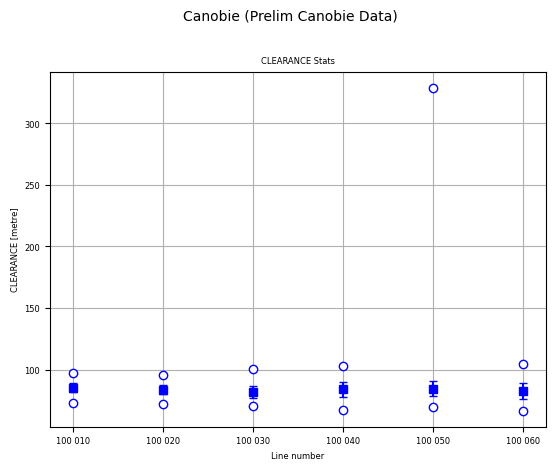

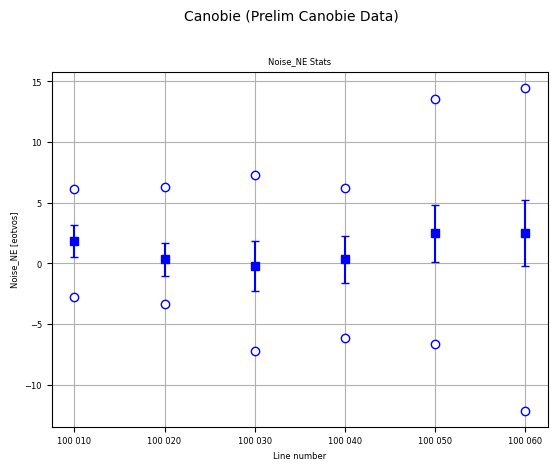

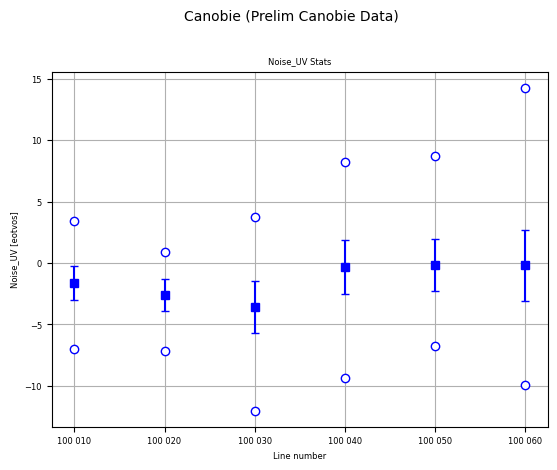

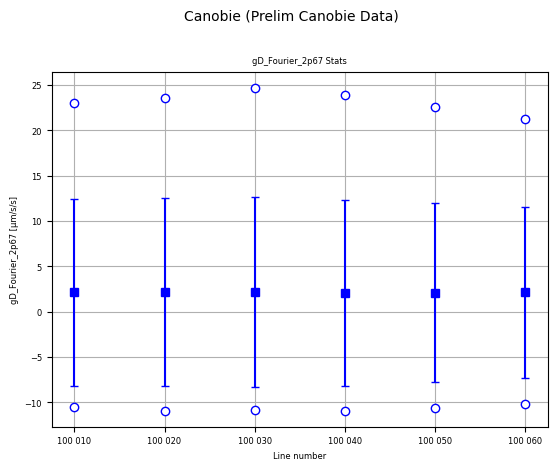

In [3]:
qc.allChanStats(canobieHDF_file, ['CLEARANCE', 'Noise_NE', 'Noise_UV', 'gD_Fourier_2p67'])